In [1]:
import os
import numpy as np
import geopandas as gpd
from PIL import Image # Primary library for JPG/PNG
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# --- Directory Configuration ---
BASE_OUT = "../data/modular_final"
META_DIR = f"{BASE_OUT}/metadata"

# Input Task Folders (Now containing .png files)
TASKS = ["masks_builtup", "masks_grassland", "masks_highveg"]
COMBINED_TASK = "masks_combined"

# Load anchors to get the universal file list and split info
gdf_anchors = gpd.read_file(f"{META_DIR}/building_anchors_10000.gpkg")

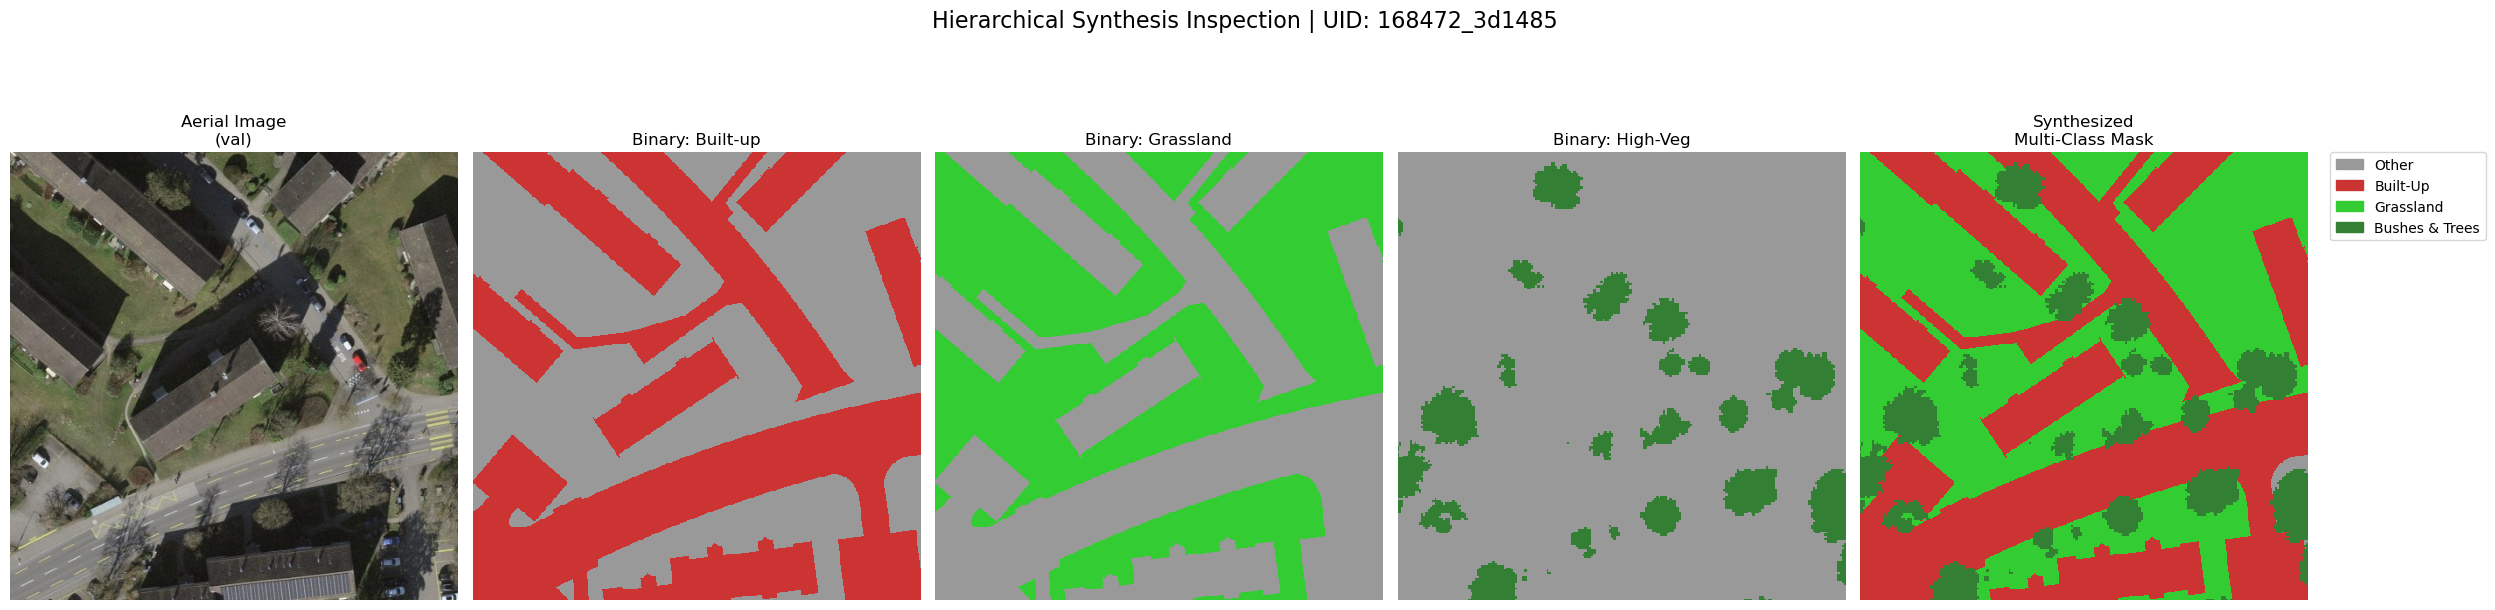

In [6]:
import random
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 1. Define your specific RGB colors (scaled 0-1)
colors = [
    (0.6, 0.6, 0.6),  # Index 0: Other - Grey
    (0.8, 0.2, 0.2),  # Index 1: Built-Up - Reddish
    (0.2, 0.8, 0.2),  # Index 2: Grassland - Greenish
    (0.2, 0.5, 0.2)   # Index 3: Bushes & Trees - Darker Green
]

# Create colormaps for the binary views using your specific class colors
cmap_built = ListedColormap([colors[0], colors[1]]) # Grey vs Red
cmap_grass = ListedColormap([colors[0], colors[2]]) # Grey vs Green
cmap_trees = ListedColormap([colors[0], colors[3]]) # Grey vs Dark Green
cmap_multi = ListedColormap(colors)                 # The full 4-color palette

# 2. Select a random sample
sample_idx = random.randint(0, len(gdf_anchors) - 1)
sample = gdf_anchors.iloc[sample_idx]
uid, split = sample['unique_id'], sample['split']

# 3. Define Paths (Assuming JPG for images and PNG for masks)
img_path = f"{BASE_OUT}/{split}/images/{uid}_swissimage.jpg"
mask_paths = {
    "Built-up": f"{BASE_OUT}/{split}/masks_builtup/{uid}_mask.png",
    "Grassland": f"{BASE_OUT}/{split}/masks_grassland/{uid}_mask.png",
    "High-Veg": f"{BASE_OUT}/{split}/masks_highveg/{uid}_mask.png",
    "Multi-Class": f"{BASE_OUT}/{split}/{COMBINED_TASK}/{uid}_mask.png"
}

# 4. Load Data
img_arr = np.array(Image.open(img_path).convert("RGB"))
m_built = np.array(Image.open(mask_paths["Built-up"]))
m_grass = np.array(Image.open(mask_paths["Grassland"]))
m_tree  = np.array(Image.open(mask_paths["High-Veg"]))
m_multi = np.array(Image.open(mask_paths["Multi-Class"]))

# 5. Visualization
fig, axs = plt.subplots(1, 5, figsize=(25, 6))

# Plot 1: Aerial
axs[0].imshow(img_arr)
axs[0].set_title(f"Aerial Image\n({split})")
axs[0].axis('off')

# Plot 2: Binary Built-up (Grey vs Red)
axs[1].imshow(m_built, cmap=cmap_built, vmin=0, vmax=1, interpolation='nearest')
axs[1].set_title("Binary: Built-up")
axs[1].axis('off')

# Plot 3: Binary Grassland (Grey vs Green)
axs[2].imshow(m_grass, cmap=cmap_grass, vmin=0, vmax=1, interpolation='nearest')
axs[2].set_title("Binary: Grassland")
axs[2].axis('off')

# Plot 4: Binary High-Veg (Grey vs Dark Green)
axs[3].imshow(m_tree, cmap=cmap_trees, vmin=0, vmax=1, interpolation='nearest')
axs[3].set_title("Binary: High-Veg")
axs[3].axis('off')

# Plot 5: Multi-Class Combined (Full Palette)
axs[4].imshow(m_multi, cmap=cmap_multi, vmin=0, vmax=3, interpolation='nearest')
axs[4].set_title("Synthesized\nMulti-Class Mask")
axs[4].axis('off')

# Add the Multi-Class Legend
labels = {0: 'Other', 1: 'Built-Up', 2: 'Grassland', 3: 'Bushes & Trees'}
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(4)]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.suptitle(f"Hierarchical Synthesis Inspection | UID: {uid}", fontsize=16, y=1.08)
plt.tight_layout()
plt.show()